# MLForecast Experiments

Machine-learning baselines using Nixtla MLForecast. Historical weather columns are not passed directly to avoid future-weather leakage.

In [1]:
import importlib

import config as shared_config
import experiment
import experiment.config
import experiment.data
import experiment.rolling_forecast.artifacts
import experiment.rolling_forecast.executors
import experiment.rolling_forecast.executors.mlforecast
import experiment.rolling_forecast.executors.neural
import experiment.rolling_forecast.runner
import experiment.rolling_forecast.runtime

importlib.reload(shared_config)
importlib.reload(experiment.config)
importlib.reload(experiment.data)
importlib.reload(experiment.rolling_forecast.artifacts)
importlib.reload(experiment.rolling_forecast.executors.mlforecast)
importlib.reload(experiment.rolling_forecast.executors.neural)
importlib.reload(experiment.rolling_forecast.executors)
importlib.reload(experiment.rolling_forecast.runtime)
importlib.reload(experiment.rolling_forecast.runner)
importlib.reload(experiment)

from experiment import DatasetBuilder, ModelSpec, RollingForecastRunner, RunConfig

In [2]:
prepared_dataset = DatasetBuilder.from_csv(
    csv_path=shared_config.CSV_PATH,
    unique_id=shared_config.UNIQUE_ID,
    remove_last_month=shared_config.REMOVE_LAST_MONTH,
    hist_exog=shared_config.HIST_EXOG_LIST,
    futr_exog=shared_config.FUTR_EXOG_LIST,
)


def build_run_config(*, use_hist_exog: bool, use_futr_exog: bool) -> RunConfig:
    return RunConfig(
        input_size=shared_config.INPUT_SIZE,
        horizon=shared_config.HORIZON,
        split_ratio=shared_config.SPLIT_RATIO,
        sliding_step_size=shared_config.SLIDING_STEP_SIZE,
        use_hist_exog=use_hist_exog,
        use_futr_exog=use_futr_exog,
        save_plots=shared_config.SAVE_PLOTS,
        random_seed=shared_config.RANDOM_SEED,
        early_stop_patience_epochs=shared_config.EARLY_STOP_PATIENCE_EPOCHS,
        ml_early_stopping_rounds=shared_config.ML_EARLY_STOPPING_ROUNDS,
        neural_loss_name=shared_config.NEURAL_LOSS_NAME,
        neural_loss_params=shared_config.NEURAL_LOSS_PARAMS,
        neural_checkpoint_mode=shared_config.CHECKPOINT_MODE,
        save_dir=shared_config.SAVE_DIR,
        plot_forecast=shared_config.PLOT_FORECAST,
        plot_loss=shared_config.PLOT_LOSS,
        plot_loss_name=shared_config.PLOT_LOSS_NAME,
        freq=shared_config.FREQ,
    )

from mlforecast import MLForecast
from mlforecast.lag_transforms import ExpandingMean, RollingMean

USE_HIST_EXOG = False
USE_FUTR_EXOG_NO_EXOG = False
USE_FUTR_EXOG_WITH_KNOWN_FUTURE = True

MLFORECAST_LAGS = [1, 2, 3, 7, 14, 28]
MLFORECAST_LAG_TRANSFORMS = {
    1: [ExpandingMean()],
    7: [RollingMean(window_size=7), RollingMean(window_size=14)],
}
MLFORECAST_DATE_FEATURES = ["dayofweek", "month"]
COMMON_MLFORECAST_PARAMS = {
    "lags": MLFORECAST_LAGS,
    "lag_transforms": MLFORECAST_LAG_TRANSFORMS,
    "date_features": MLFORECAST_DATE_FEATURES,
    "num_threads": 1,
}

run_config_no_exog = build_run_config(
    use_hist_exog=USE_HIST_EXOG,
    use_futr_exog=USE_FUTR_EXOG_NO_EXOG,
)
run_config_futr_exog = build_run_config(
    use_hist_exog=USE_HIST_EXOG,
    use_futr_exog=USE_FUTR_EXOG_WITH_KNOWN_FUTURE,
)
runner_no_exog = RollingForecastRunner(
    prepared_dataset=prepared_dataset,
    run_config=run_config_no_exog,
)
runner_futr_exog = RollingForecastRunner(
    prepared_dataset=prepared_dataset,
    run_config=run_config_futr_exog,
)


def run_no_exog_and_futr_exog(model_spec: ModelSpec):
    no_exog_result = runner_no_exog.run(model_spec)
    print("no_exog", no_exog_result.summary())
    print(f"no_exog rolling_raw_path: {no_exog_result.rolling_raw_path}")

    futr_exog_result = runner_futr_exog.run(model_spec)
    print("futr_exog", futr_exog_result.summary())
    print(f"futr_exog rolling_raw_path: {futr_exog_result.rolling_raw_path}")
    return {"no_exog": no_exog_result, "futr_exog": futr_exog_result}

Seed set to 2026


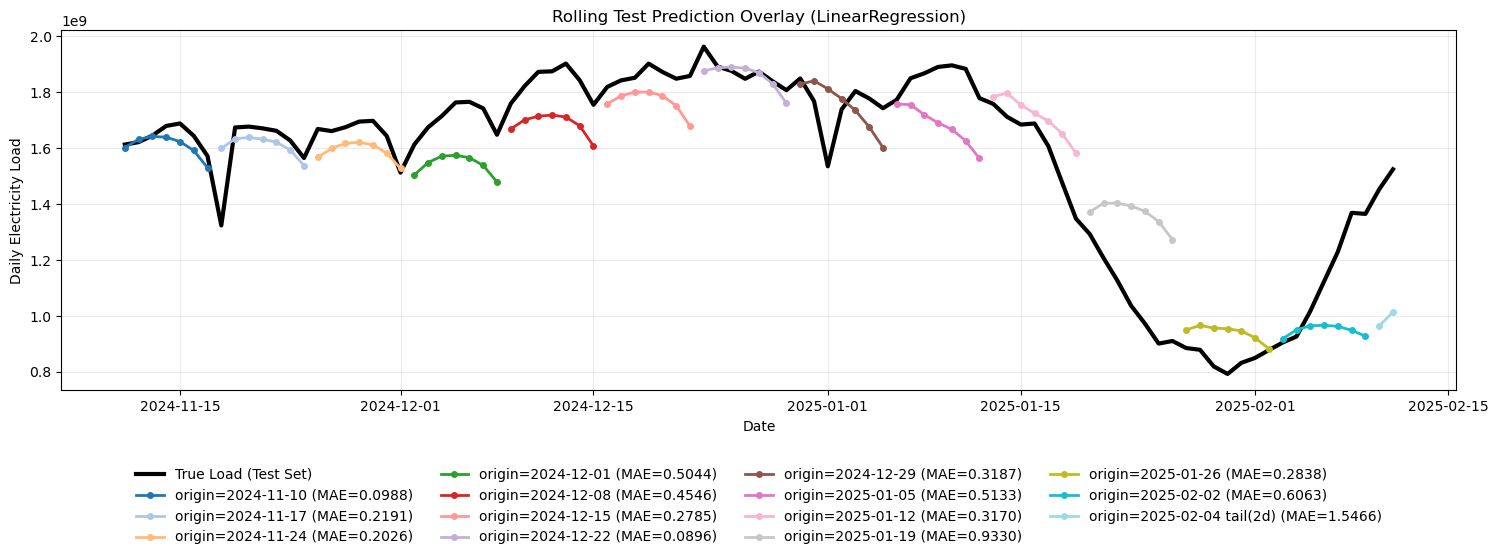

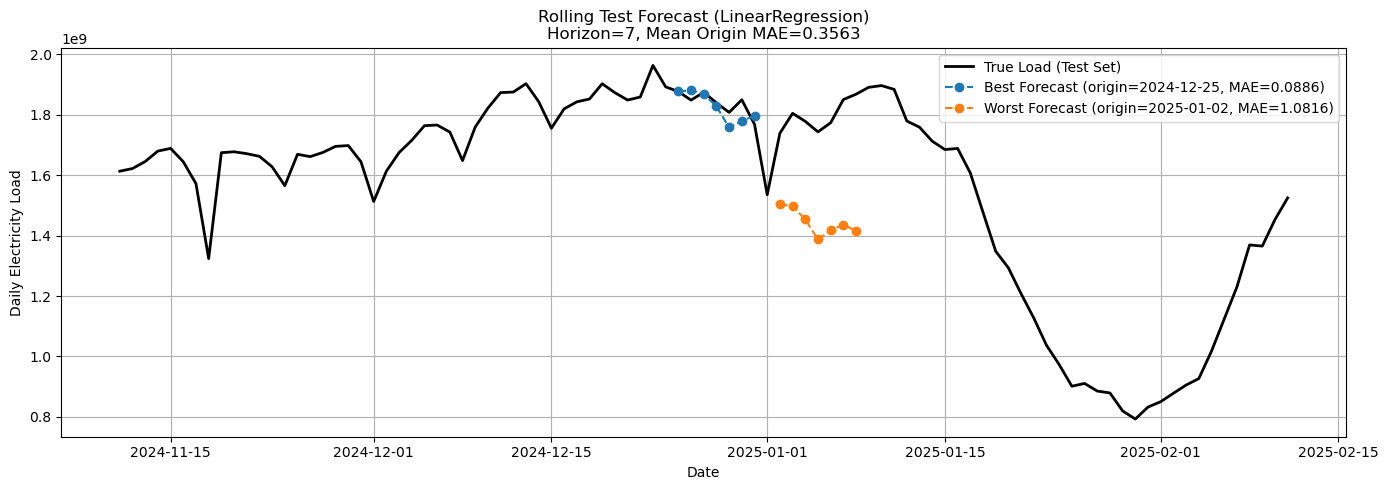

Seed set to 2026


no_exog {'model_name': 'LinearRegression', 'val_overall_mape': 12.720124443011102, 'overall_mape': 8.310982319544133, 'skipped': False, 'skip_reason': None, 'artifact_dir': 'artifacts\\LinearRegression_no_feat\\20260420_162258', 'best_model_path': None, 'val_best_model_path': None, 'test_best_model_path': None, 'rolling_raw_path': 'artifacts\\LinearRegression_no_feat\\20260420_162258\\rolling_test_raw.csv', 'overlay_plot_path': 'artifacts\\LinearRegression_no_feat\\20260420_162258\\rolling_test_overlay.png'}
no_exog rolling_raw_path: artifacts\LinearRegression_no_feat\20260420_162258\rolling_test_raw.csv


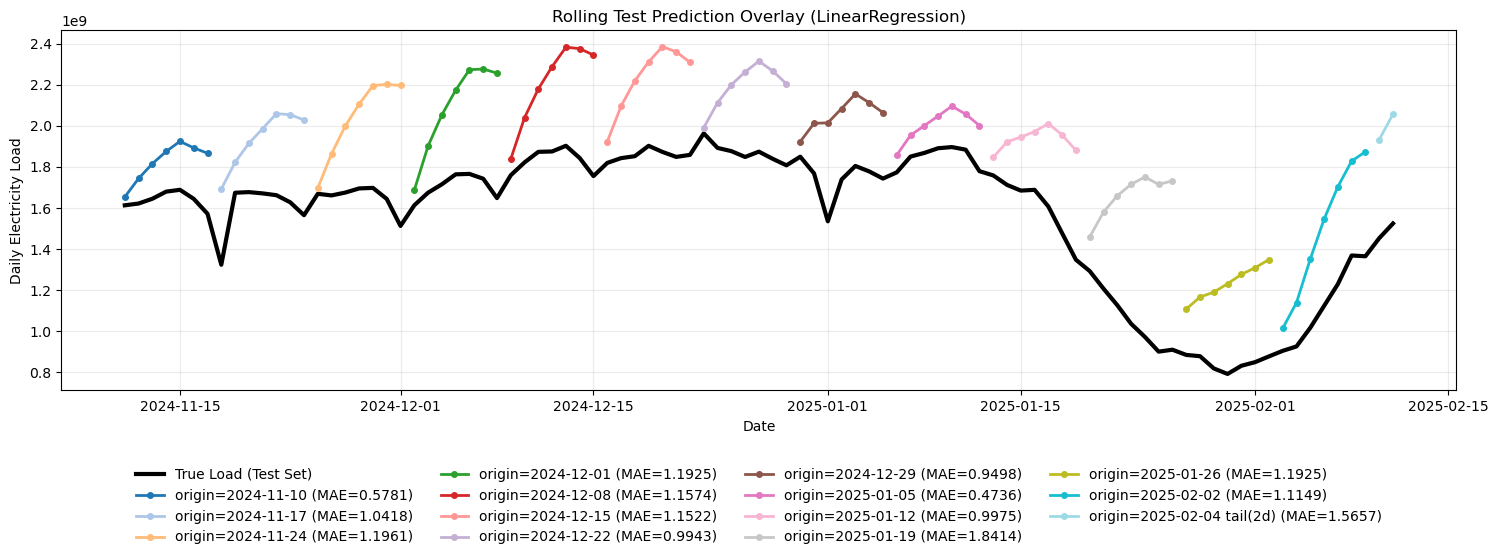

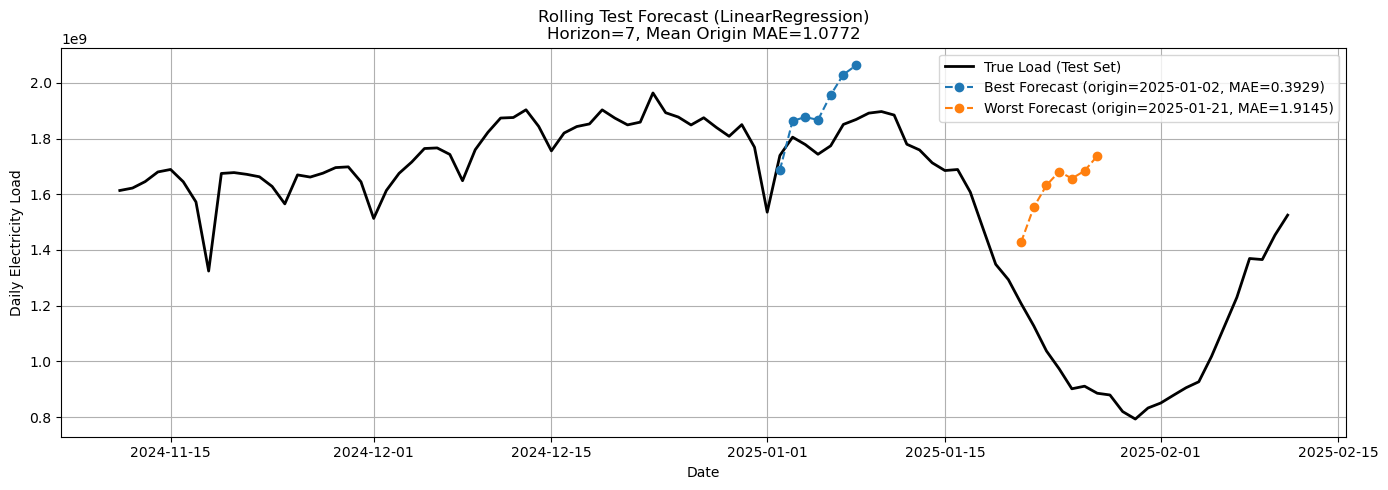

futr_exog {'model_name': 'LinearRegression', 'val_overall_mape': 18.478954424373374, 'overall_mape': 24.78504616040338, 'skipped': False, 'skip_reason': None, 'artifact_dir': 'artifacts\\LinearRegression_futr_feat\\20260420_162308', 'best_model_path': None, 'val_best_model_path': None, 'test_best_model_path': None, 'rolling_raw_path': 'artifacts\\LinearRegression_futr_feat\\20260420_162308\\rolling_test_raw.csv', 'overlay_plot_path': 'artifacts\\LinearRegression_futr_feat\\20260420_162308\\rolling_test_overlay.png'}
futr_exog rolling_raw_path: artifacts\LinearRegression_futr_feat\20260420_162308\rolling_test_raw.csv


In [3]:
from sklearn.linear_model import LinearRegression

linear_regression_spec = ModelSpec(
    name="LinearRegression",
    model_type="mlforecast",
    model_cls=MLForecast,
    model_params={
        **COMMON_MLFORECAST_PARAMS,
        "models": LinearRegression(),
    },
    supports_hist_exog=False,
    supports_future_exog=True,
)

linear_regression_results = run_no_exog_and_futr_exog(linear_regression_spec)

Seed set to 2026
d:\miniconda\envs\dl\Lib\site-packages\sklearn\linear_model\_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=4.78864e-18): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
d:\miniconda\envs\dl\Lib\site-packages\sklearn\linear_model\_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=5.80768e-18): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


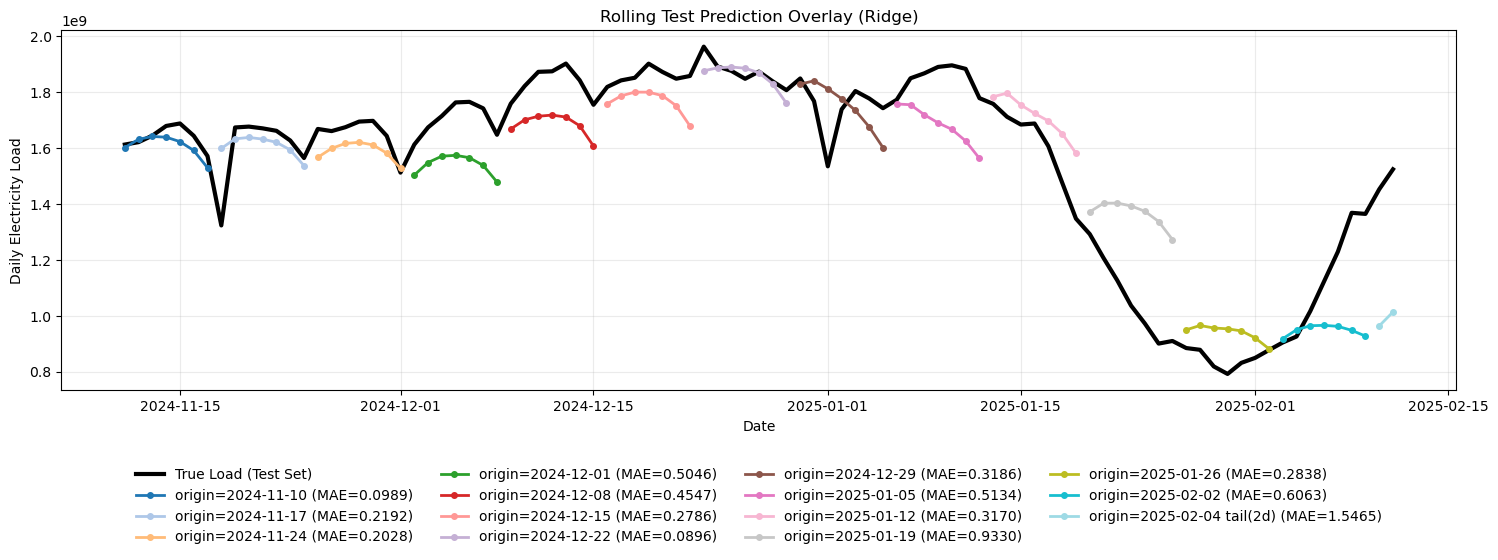

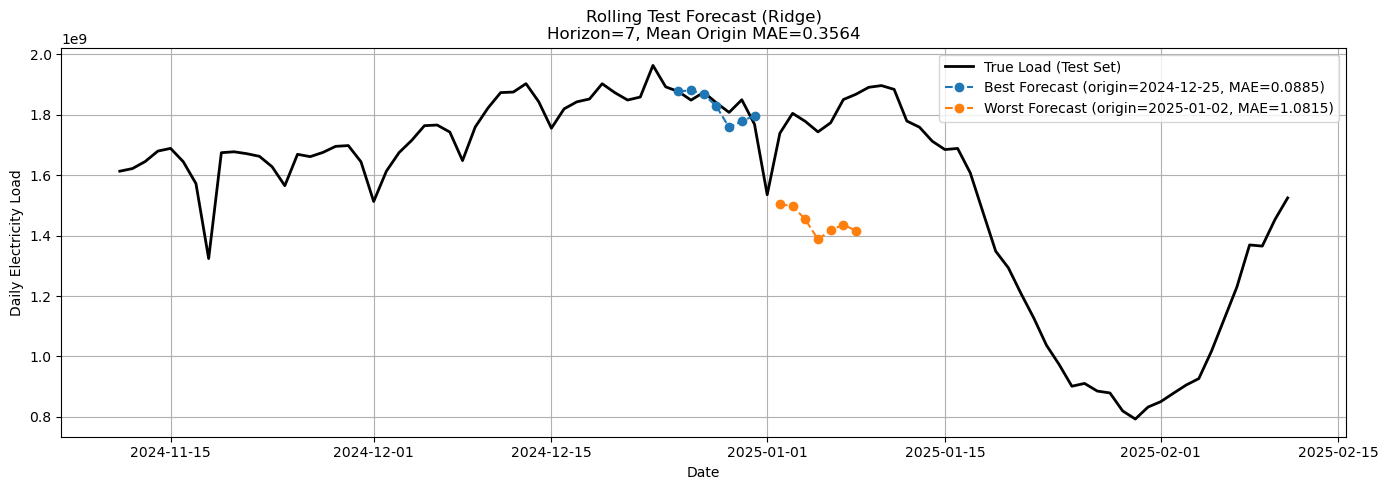

Seed set to 2026


no_exog {'model_name': 'Ridge', 'val_overall_mape': 12.721188959225888, 'overall_mape': 8.311389195063214, 'skipped': False, 'skip_reason': None, 'artifact_dir': 'artifacts\\Ridge_no_feat\\20260420_162321', 'best_model_path': None, 'val_best_model_path': None, 'test_best_model_path': None, 'rolling_raw_path': 'artifacts\\Ridge_no_feat\\20260420_162321\\rolling_test_raw.csv', 'overlay_plot_path': 'artifacts\\Ridge_no_feat\\20260420_162321\\rolling_test_overlay.png'}
no_exog rolling_raw_path: artifacts\Ridge_no_feat\20260420_162321\rolling_test_raw.csv


d:\miniconda\envs\dl\Lib\site-packages\sklearn\linear_model\_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=4.25674e-21): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
d:\miniconda\envs\dl\Lib\site-packages\sklearn\linear_model\_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=4.14537e-21): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


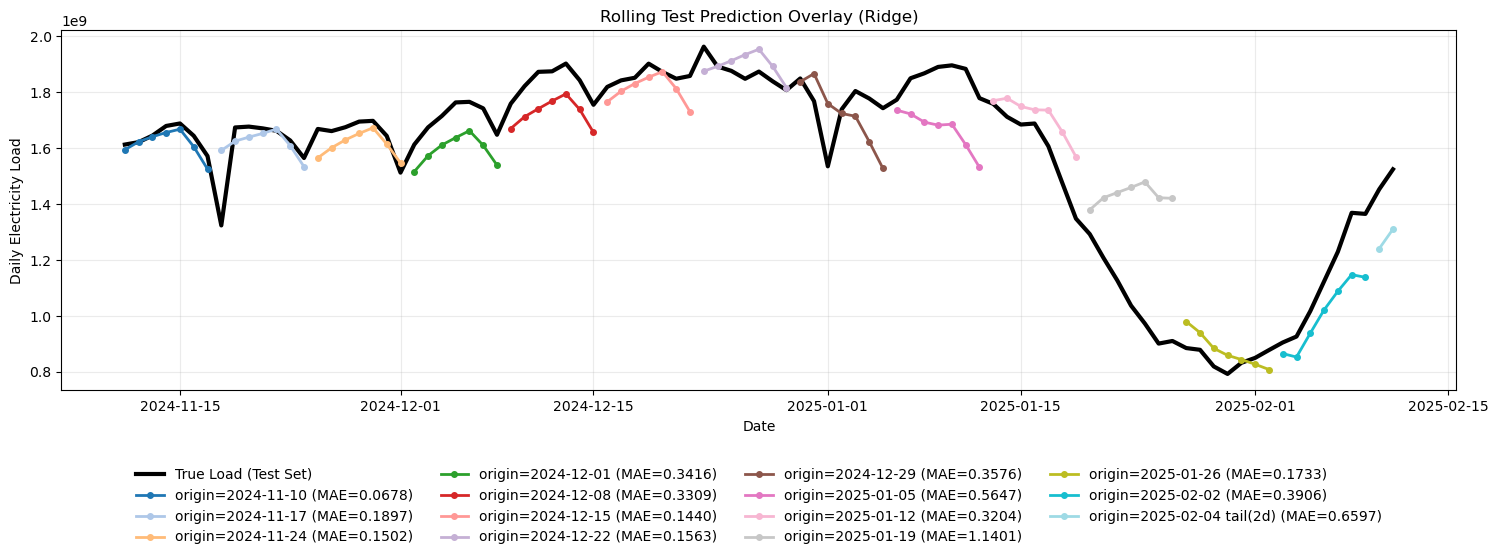

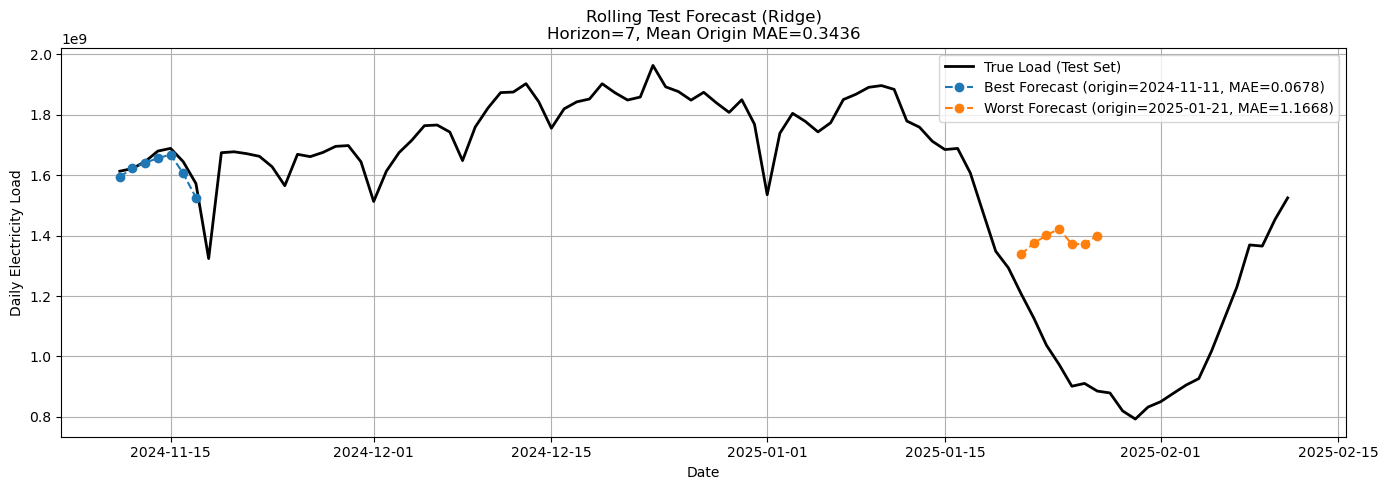

futr_exog {'model_name': 'Ridge', 'val_overall_mape': 12.022846498150445, 'overall_mape': 8.321097498617593, 'skipped': False, 'skip_reason': None, 'artifact_dir': 'artifacts\\Ridge_futr_feat\\20260420_162330', 'best_model_path': None, 'val_best_model_path': None, 'test_best_model_path': None, 'rolling_raw_path': 'artifacts\\Ridge_futr_feat\\20260420_162330\\rolling_test_raw.csv', 'overlay_plot_path': 'artifacts\\Ridge_futr_feat\\20260420_162330\\rolling_test_overlay.png'}
futr_exog rolling_raw_path: artifacts\Ridge_futr_feat\20260420_162330\rolling_test_raw.csv


In [4]:
from sklearn.linear_model import Ridge

ridge_spec = ModelSpec(
    name="Ridge",
    model_type="mlforecast",
    model_cls=MLForecast,
    model_params={
        **COMMON_MLFORECAST_PARAMS,
        "models": Ridge(alpha=1.0, random_state=shared_config.RANDOM_SEED),
    },
    supports_hist_exog=False,
    supports_future_exog=True,
)

ridge_results = run_no_exog_and_futr_exog(ridge_spec)

Seed set to 2026


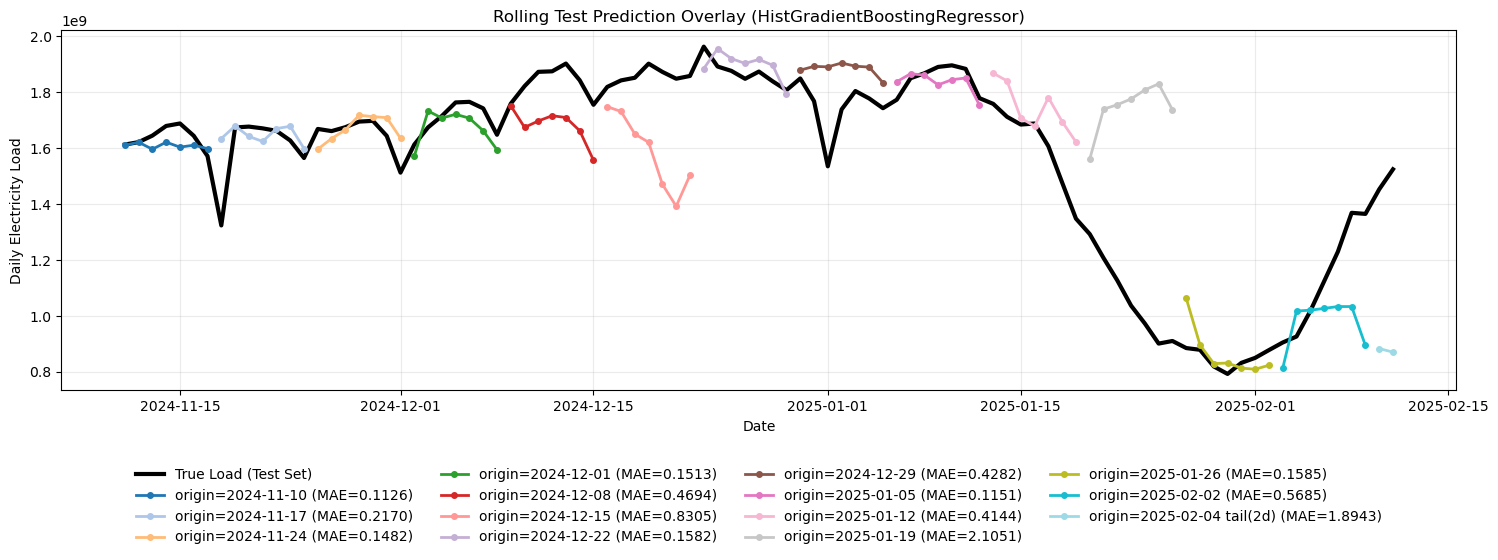

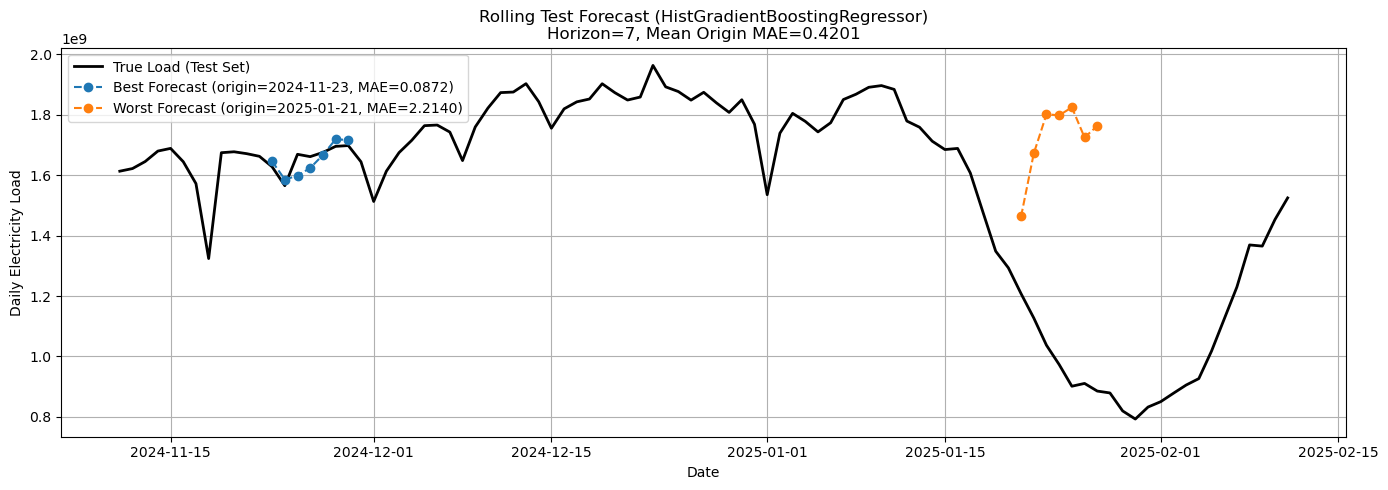

Seed set to 2026


no_exog {'model_name': 'HistGradientBoostingRegressor', 'val_overall_mape': 8.452022819764059, 'overall_mape': 10.161072670703838, 'skipped': False, 'skip_reason': None, 'artifact_dir': 'artifacts\\HistGradientBoostingRegressor_no_feat\\20260420_162343', 'best_model_path': None, 'val_best_model_path': None, 'test_best_model_path': None, 'rolling_raw_path': 'artifacts\\HistGradientBoostingRegressor_no_feat\\20260420_162343\\rolling_test_raw.csv', 'overlay_plot_path': 'artifacts\\HistGradientBoostingRegressor_no_feat\\20260420_162343\\rolling_test_overlay.png'}
no_exog rolling_raw_path: artifacts\HistGradientBoostingRegressor_no_feat\20260420_162343\rolling_test_raw.csv


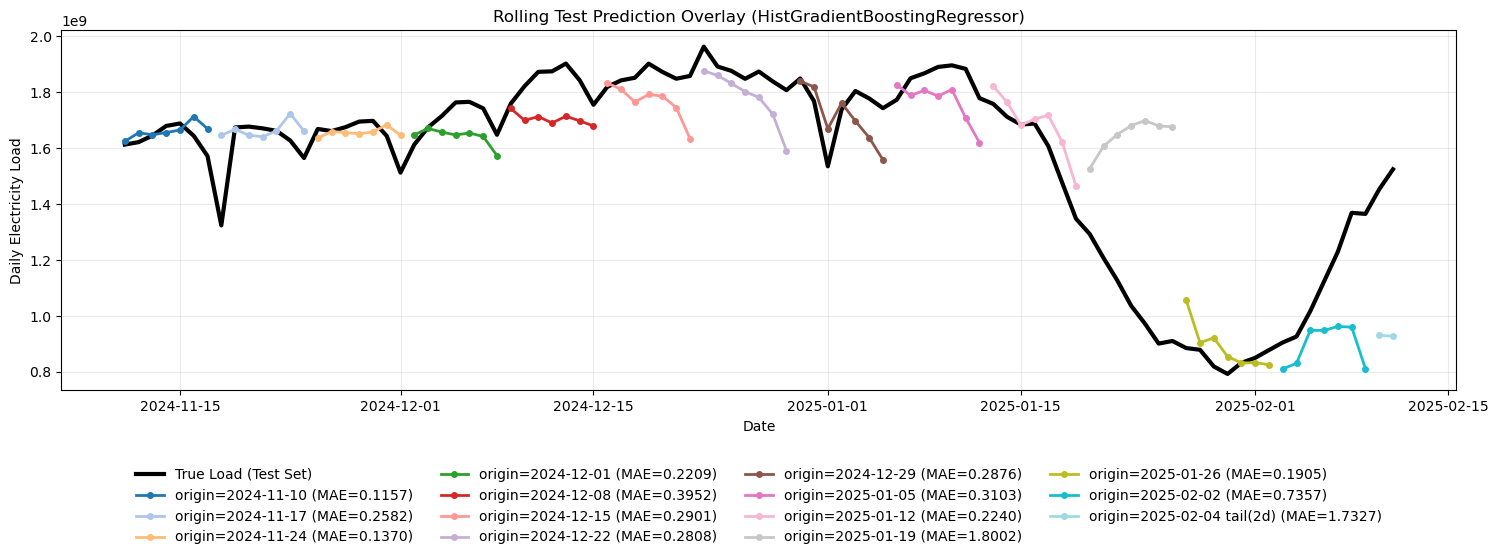

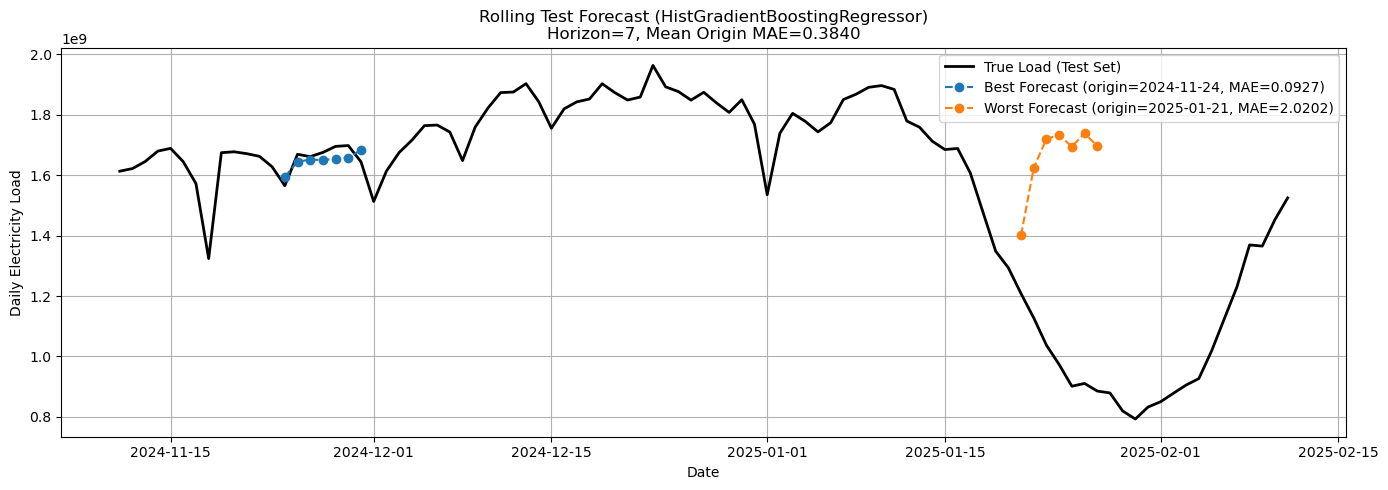

futr_exog {'model_name': 'HistGradientBoostingRegressor', 'val_overall_mape': 6.380958226774303, 'overall_mape': 9.287924149452113, 'skipped': False, 'skip_reason': None, 'artifact_dir': 'artifacts\\HistGradientBoostingRegressor_futr_feat\\20260420_162406', 'best_model_path': None, 'val_best_model_path': None, 'test_best_model_path': None, 'rolling_raw_path': 'artifacts\\HistGradientBoostingRegressor_futr_feat\\20260420_162406\\rolling_test_raw.csv', 'overlay_plot_path': 'artifacts\\HistGradientBoostingRegressor_futr_feat\\20260420_162406\\rolling_test_overlay.png'}
futr_exog rolling_raw_path: artifacts\HistGradientBoostingRegressor_futr_feat\20260420_162406\rolling_test_raw.csv


In [5]:
from sklearn.ensemble import HistGradientBoostingRegressor

hist_gradient_boosting_spec = ModelSpec(
    name="HistGradientBoostingRegressor",
    model_type="mlforecast",
    model_cls=MLForecast,
    model_params={
        **COMMON_MLFORECAST_PARAMS,
        "models": HistGradientBoostingRegressor(
            max_iter=300,
            learning_rate=0.05,
            random_state=shared_config.RANDOM_SEED,
        ),
    },
    supports_hist_exog=False,
    supports_future_exog=True,
)

hist_gradient_boosting_results = run_no_exog_and_futr_exog(hist_gradient_boosting_spec)

Seed set to 2026


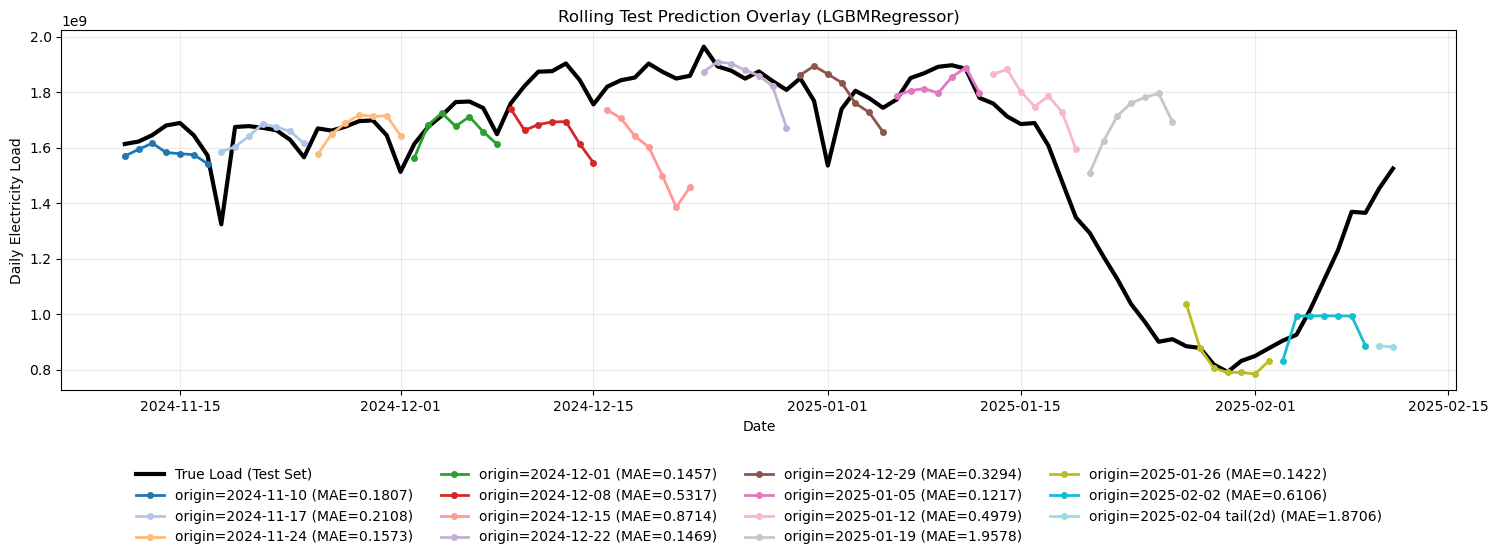

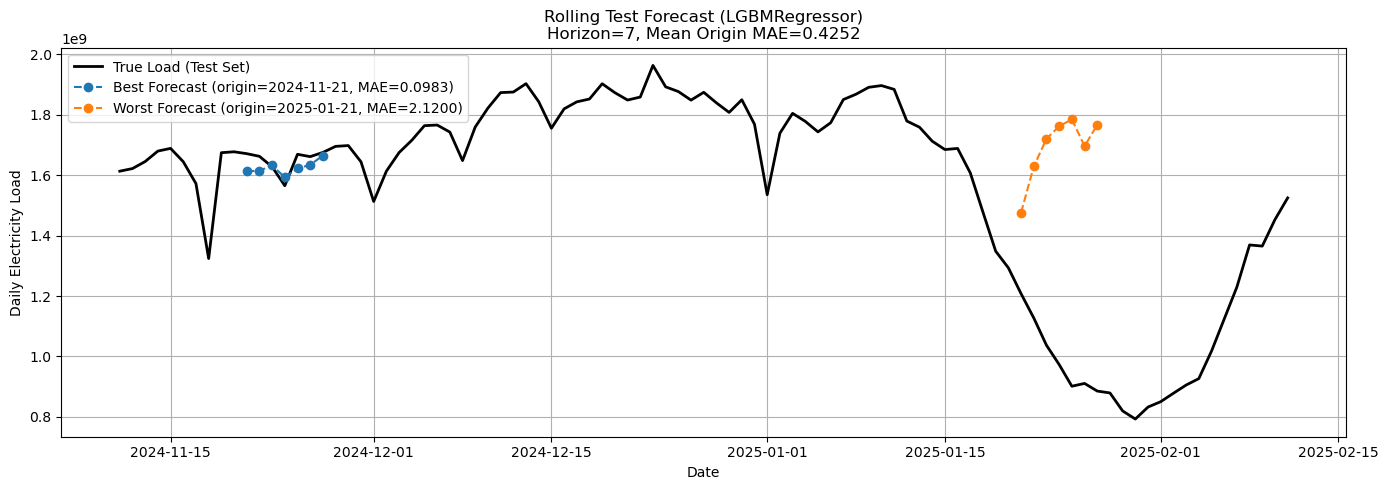

Seed set to 2026


no_exog {'model_name': 'LGBMRegressor', 'val_overall_mape': 10.074335226406543, 'overall_mape': 10.168022714426526, 'skipped': False, 'skip_reason': None, 'artifact_dir': 'artifacts\\LGBMRegressor_no_feat\\20260420_162425', 'best_model_path': None, 'val_best_model_path': None, 'test_best_model_path': None, 'rolling_raw_path': 'artifacts\\LGBMRegressor_no_feat\\20260420_162425\\rolling_test_raw.csv', 'overlay_plot_path': 'artifacts\\LGBMRegressor_no_feat\\20260420_162425\\rolling_test_overlay.png'}
no_exog rolling_raw_path: artifacts\LGBMRegressor_no_feat\20260420_162425\rolling_test_raw.csv


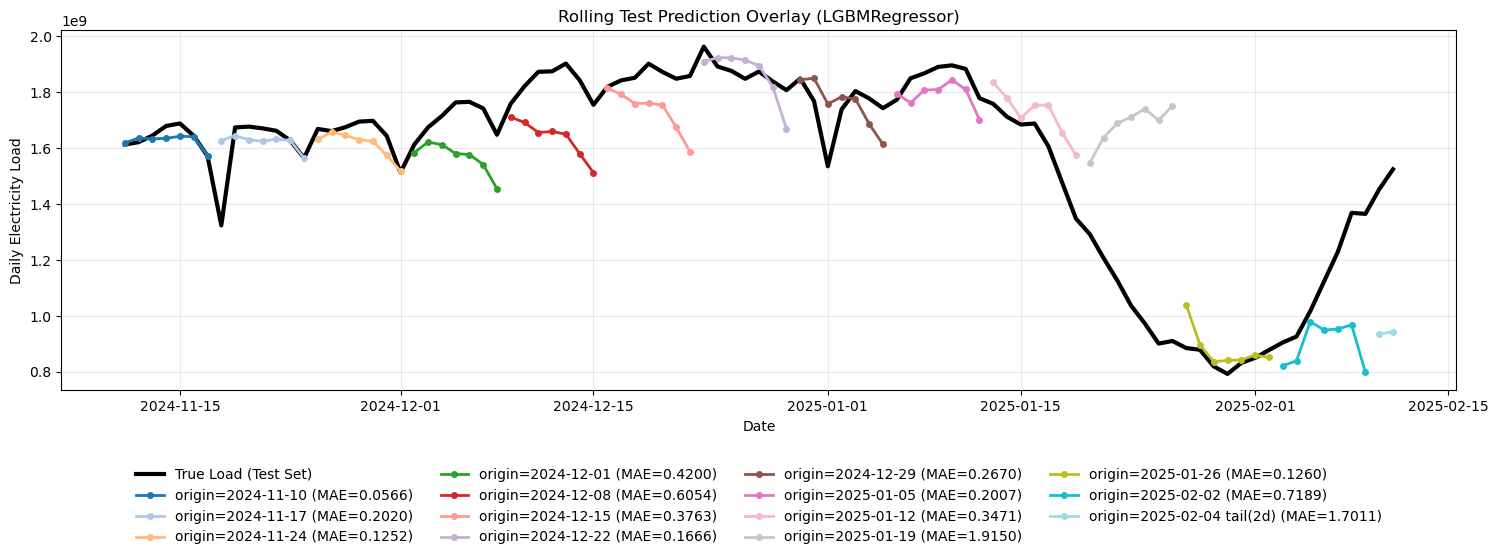

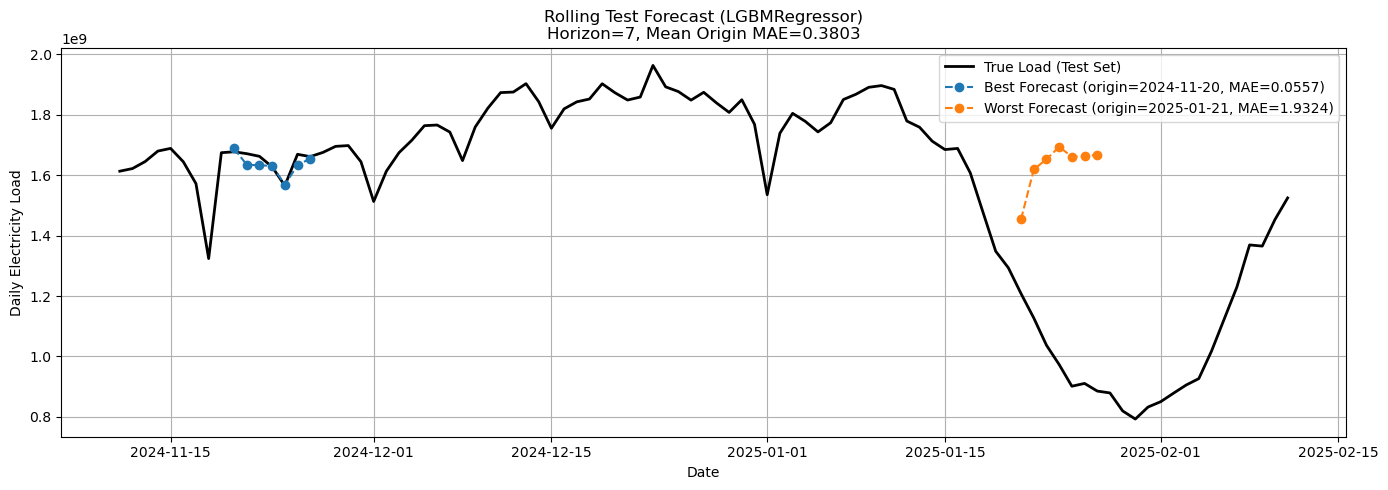

futr_exog {'model_name': 'LGBMRegressor', 'val_overall_mape': 5.4575995104448864, 'overall_mape': 9.217913219703947, 'skipped': False, 'skip_reason': None, 'artifact_dir': 'artifacts\\LGBMRegressor_futr_feat\\20260420_162436', 'best_model_path': None, 'val_best_model_path': None, 'test_best_model_path': None, 'rolling_raw_path': 'artifacts\\LGBMRegressor_futr_feat\\20260420_162436\\rolling_test_raw.csv', 'overlay_plot_path': 'artifacts\\LGBMRegressor_futr_feat\\20260420_162436\\rolling_test_overlay.png'}
futr_exog rolling_raw_path: artifacts\LGBMRegressor_futr_feat\20260420_162436\rolling_test_raw.csv


In [6]:
from lightgbm import LGBMRegressor

lgbm_spec = ModelSpec(
    name="LGBMRegressor",
    model_type="mlforecast",
    model_cls=MLForecast,
    model_params={
        **COMMON_MLFORECAST_PARAMS,
        "models": LGBMRegressor(
            n_estimators=300,
            learning_rate=0.05,
            num_leaves=15,
            random_state=shared_config.RANDOM_SEED,
            verbosity=-1,
        ),
    },
    supports_hist_exog=False,
    supports_future_exog=True,
)

lgbm_results = run_no_exog_and_futr_exog(lgbm_spec)

In [7]:
from xgboost import XGBRegressor

xgb_spec = ModelSpec(
    name="XGBRegressor",
    model_type="mlforecast",
    model_cls=MLForecast,
    model_params={
        **COMMON_MLFORECAST_PARAMS,
        "models": XGBRegressor(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=3,
            subsample=0.9,
            colsample_bytree=0.9,
            objective="reg:squarederror",
            random_state=shared_config.RANDOM_SEED,
            n_jobs=1,
        ),
    },
    supports_hist_exog=False,
    supports_future_exog=True,
)

xgb_results = run_no_exog_and_futr_exog(xgb_spec)

ModuleNotFoundError: No module named 'xgboost'